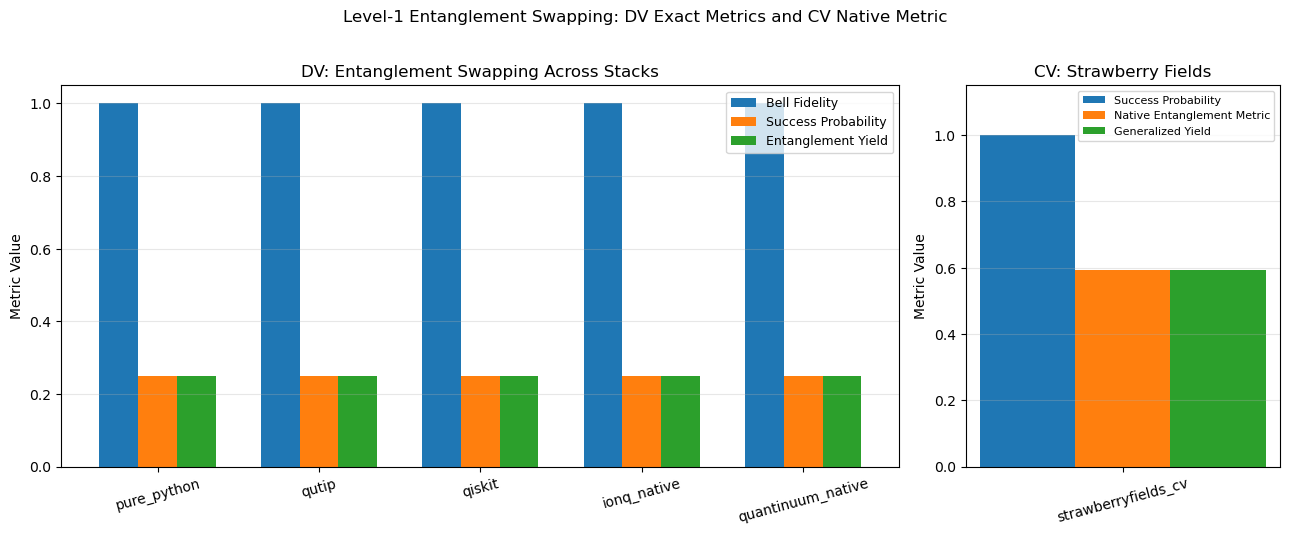

In [5]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np


DV_FILES = [
    "results/pure_python.json",
    "results/qutip.json",
    "results/qiskit.json",
    "results/ionq_native.json",
    "results/quantinuum_native.json",
]

CV_FILE = "results/strawberryfields_cv.json"


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def main():
    os.makedirs("figures", exist_ok=True)

    dv_rows = [load_json(path) for path in DV_FILES]
    cv_row = load_json(CV_FILE)

    # -----------------------------
    # DV data
    # -----------------------------
    dv_labels = [r["stack"] for r in dv_rows]
    dv_success = [r["success_probability"] for r in dv_rows]
    dv_fidelity = [r["bell_fidelity"] for r in dv_rows]
    dv_yield = [r["entanglement_yield"] for r in dv_rows]

    # -----------------------------
    # CV data
    # -----------------------------
    cv_labels = ["strawberryfields_cv"]
    cv_success = [cv_row["success_probability"]]
    cv_native = [cv_row["native_entanglement_metric"]]
    cv_yield = [cv_row["generalized_entanglement_yield"]]

    # -----------------------------
    # Figure layout
    # -----------------------------
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [4.8, 1.8]}
    )

    # -----------------------------
    # Left panel: DV
    # -----------------------------
    x1 = np.arange(len(dv_labels))
    width1 = 0.24

    ax1.bar(x1 - width1, dv_fidelity, width1, label="Bell Fidelity")
    ax1.bar(x1, dv_success, width1, label="Success Probability")
    ax1.bar(x1 + width1, dv_yield, width1, label="Entanglement Yield")

    ax1.set_title("DV: Entanglement Swapping Across Stacks")
    ax1.set_ylabel("Metric Value")
    ax1.set_xticks(x1)
    ax1.set_xticklabels(dv_labels, rotation=15)
    ax1.set_ylim(0.0, 1.05)
    ax1.grid(axis="y", alpha=0.3)
    ax1.legend(fontsize=9)

    # -----------------------------
    # Right panel: CV
    # -----------------------------
    x2 = np.arange(len(cv_labels))
    width2 = 0.24

    ax2.bar(x2 - width2, cv_success, width2, label="Success Probability")
    ax2.bar(x2, cv_native, width2, label="Native Entanglement Metric")
    ax2.bar(x2 + width2, cv_yield, width2, label="Generalized Yield")

    ax2.set_title("CV: Strawberry Fields")
    ax2.set_ylabel("Metric Value")
    ax2.set_xticks(x2)
    ax2.set_xticklabels(cv_labels, rotation=15)

    # Make CV panel autoscale, but avoid tiny/odd ranges
    cv_max = max(cv_success + cv_native + cv_yield)
    ax2.set_ylim(0.0, max(1.05, 1.15 * cv_max))
    ax2.grid(axis="y", alpha=0.3)
    ax2.legend(fontsize=8)

    fig.suptitle("Level-1 Entanglement Swapping: DV Exact Metrics and CV Native Metric", y=1.02)
    plt.tight_layout()
    plt.savefig("figures/ent_swap_level1_twopanel.png", dpi=220, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    main()